# MPro DiGress Filtered GINE pIC50 Regressor

This notebook trains a GINE regressor on MPro compounds augmented with DiGress-generated molecules that fall **inside the chemical space** already covered by the MPro dataset.

The filtering pipeline proceeds in four stages:

1. **Read MPro Info.csv** and derive the valid pIC50 range and heavy-atom-count range from the full database.
2. **Build a combined DiGress dataset** from the two pseudo-label CSVs, deduplicate by SMILES, and keep only molecules whose pIC50 and molecule size fall within the MPro bounds.
3. **Construct a configurable augmented training split**: all original MPro train molecules plus a user-controlled percentage of DiGress molecules sampled from the filtered pool. Validation and test splits are unchanged.
4. **Train the GINE regressor** with the best hyperparameters from the first notebook and report the standard regression and ROC/AUC metrics on the test set.


In [2]:
from __future__ import annotations

# Standard library imports
import copy
import json
import math
import random
from pathlib import Path
from typing import Any, Dict, List

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from rdkit import Chem, RDLogger
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve
from torch.utils.data import DataLoader, Dataset
import datetime

In [3]:
# Control how many DiGress molecules are appended relative to the MPro train split.
# 100 means append one DiGress molecule per MPro train molecule (the previous 50/50 setup).
# 50 means append half as many DiGress molecules as MPro train molecules.
DIGRESS_APPEND_PERCENT = 50

In [4]:
RDLogger.DisableLog('rdApp.*')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


def print_banner(title: str, width: int = 88, char: str = '=') -> None:
    rule = char * width
    print(f"\n{rule}\n{title}\n{rule}")


def display_key_values(title: str, values: Dict[str, Any]) -> None:
    print_banner(title)
    frame = pd.DataFrame({'value': pd.Series(values, dtype='object')})
    display(frame)


def display_metric_table(title: str, metrics: Dict[str, float], digits: int = 4) -> None:
    print_banner(title)
    metric_frame = pd.DataFrame(
        {'metric': list(metrics.keys()), 'value': list(metrics.values())}
    )
    display(metric_frame.round(digits))


display_key_values(
    'Runtime context',
    {
        'Random seed': SEED,
        'Device': str(DEVICE),
        'PyTorch version': torch.__version__,
        'NumPy version': np.__version__,
        'Pandas version': pd.__version__,
    },
)



Runtime context


,value
Random seed,42
Device,cpu
PyTorch version,2.8.0+cpu
NumPy version,1.26.4
Pandas version,2.3.1


## Paths and Configuration

Centralized paths and hyperparameter loading.  Edit this cell first if any file locations change.


In [5]:
def find_repo_root(start_path: Path) -> Path:
    current = start_path.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / 'MPro-URV_Version2').exists():
            return candidate
    raise FileNotFoundError('Could not locate the repository root containing MPro-URV_Version2.')


REPO_ROOT = find_repo_root(Path.cwd())
DATA_ROOT = REPO_ROOT / 'MPro-URV_Version2'
SMI_DIR = DATA_ROOT / 'Ligand' / 'Ligand_SMI'
INFO_CSV = DATA_ROOT / 'Info.csv'
TRAIN_CSV = DATA_ROOT / 'train.csv'
VAL_CSV = DATA_ROOT / 'val.csv'
TEST_CSV = DATA_ROOT / 'test.csv'

ARTIFACT_DIR = REPO_ROOT / 'notebooks' / 'mpro_gine_regression' / 'artifacts'
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
HPARAMS_PATH = ARTIFACT_DIR / 'gine_best_hparams.json'

EXTERNAL_CSV_14 = ARTIFACT_DIR / 'external_predictions_14Apr2026.csv'
EXTERNAL_CSV_21 = ARTIFACT_DIR / 'external_predictions_21Apr2026.csv'

GRAPH_CACHE = ARTIFACT_DIR / 'mpro_graph_cache.pt'
CHECKPOINT_PATH = ARTIFACT_DIR / 'gine_filtered_digress_pic50_regressor.pt'
PREDICTIONS_PATH = ARTIFACT_DIR / 'filtered_digress_test_predictions.csv'
HISTORY_PATH = ARTIFACT_DIR / 'filtered_digress_training_history.json'

# Whether to allow DiGress molecules slightly outside the MPro range.
# Set to 0.0 for hard clipping, or a positive number for a small buffer.
PIC50_BUFFER = 0.0
SIZE_BUFFER = 0

ACTIVE_THRESHOLD = 6.0
FORCE_REBUILD_GRAPHS = False
LOSS_NAME = 'rmse'

if not HPARAMS_PATH.exists():
    raise FileNotFoundError(f'Best hyperparameters file not found at {HPARAMS_PATH}')

with HPARAMS_PATH.open('r', encoding='utf-8') as handle:
    hparams = json.load(handle)

BATCH_SIZE = 128
HIDDEN_DIM = int(hparams.get('hidden_dim', 128))
NUM_LAYERS = int(hparams.get('num_layers', 4))
DROPOUT = float(hparams.get('dropout', 0.15))
LEARNING_RATE = float(hparams.get('learning_rate', 1e-3))
WEIGHT_DECAY = float(hparams.get('weight_decay', 1e-4))
MAX_EPOCHS = int(hparams.get('max_epochs', 300))
PATIENCE = int(hparams.get('patience', 40))

BASE_MODEL_CONFIG = {'hidden_dim': HIDDEN_DIM, 'num_layers': NUM_LAYERS, 'dropout': DROPOUT}
BASE_TRAINING_CONFIG = {
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'max_epochs': MAX_EPOCHS,
    'patience': PATIENCE,
    'loss_name': LOSS_NAME,
}

display_key_values('Resolved paths', {
    'Repository root': REPO_ROOT,
    'Data root': DATA_ROOT,
    'Info CSV': INFO_CSV,
    'Artifact directory': ARTIFACT_DIR,
    'Checkpoint path': CHECKPOINT_PATH,
    'External CSV (14Apr2026)': EXTERNAL_CSV_14,
    'External CSV (21Apr2026)': EXTERNAL_CSV_21,
})



Resolved paths


,value
Repository root,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Data root,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Info CSV,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Artifact directory,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
Checkpoint path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
External CSV (14Apr2026),C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...
External CSV (21Apr2026),C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...


## Step 1 — MPro Chemical Space Analysis

Read the full MPro database from `Info.csv` and derive:

- The **pIC50 range** `[pic50_min, pic50_max]`  
- The **molecule size range** `[size_min, size_max]` measured in heavy atoms (no hydrogens)

These bounds define the chemical space used to filter the DiGress-generated molecules in the next step.



MPro chemical space bounds


,value
Total MPro compounds (with valid SMILES + pIC50),378
pIC50 min,4.0042
pIC50 max,8.5686
pIC50 mean,5.9522
pIC50 std,0.9779
Heavy atoms min,16
Heavy atoms max,50
Heavy atoms mean,28.25


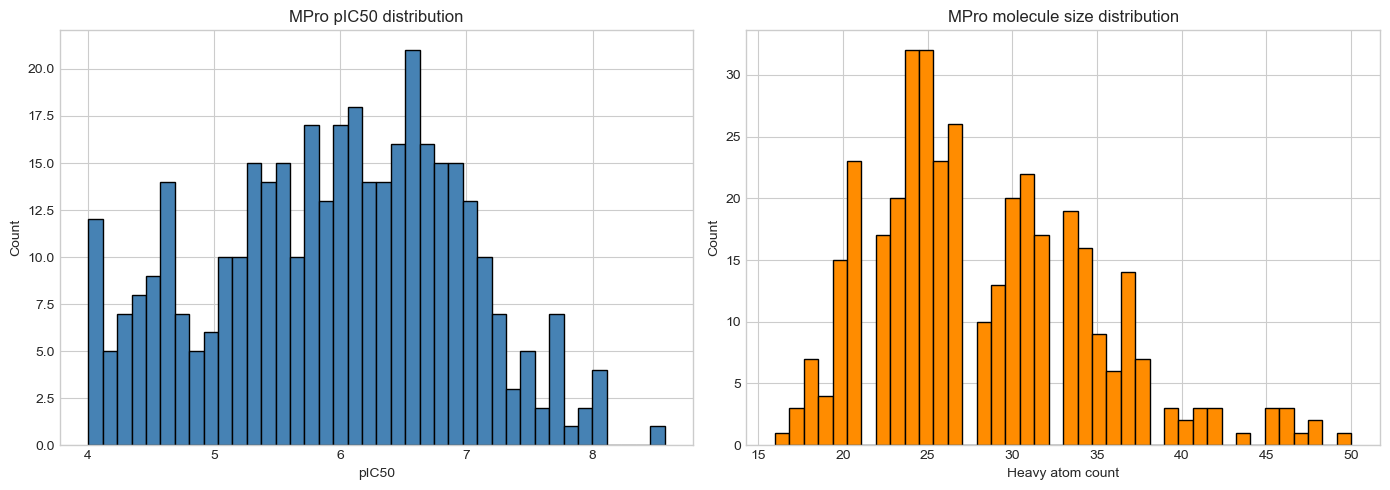

In [6]:
def get_heavy_atom_count(smiles: str) -> int | None:
    """Return the number of heavy atoms in a SMILES string, or None if unparseable."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return mol.GetNumAtoms()


# Load full MPro database.
info_df = pd.read_csv(INFO_CSV, sep=';')
info_df = info_df[['pIC50', 'SMILES']].copy()
info_df['pIC50'] = pd.to_numeric(info_df['pIC50'], errors='coerce')
info_df['SMILES'] = info_df['SMILES'].fillna('').astype(str).str.strip()
info_df = info_df.loc[info_df['SMILES'].ne('') & info_df['pIC50'].notna()].copy()

# Compute heavy atom count for every molecule.
info_df['heavy_atoms'] = info_df['SMILES'].map(get_heavy_atom_count)
info_df = info_df.dropna(subset=['heavy_atoms']).copy()
info_df['heavy_atoms'] = info_df['heavy_atoms'].astype(int)

# Derive chemical space bounds.
MPRO_PIC50_MIN = float(info_df['pIC50'].min())
MPRO_PIC50_MAX = float(info_df['pIC50'].max())
MPRO_SIZE_MIN = int(info_df['heavy_atoms'].min())
MPRO_SIZE_MAX = int(info_df['heavy_atoms'].max())

display_key_values(
    'MPro chemical space bounds',
    {
        'Total MPro compounds (with valid SMILES + pIC50)': len(info_df),
        'pIC50 min': round(MPRO_PIC50_MIN, 4),
        'pIC50 max': round(MPRO_PIC50_MAX, 4),
        'pIC50 mean': round(float(info_df['pIC50'].mean()), 4),
        'pIC50 std': round(float(info_df['pIC50'].std()), 4),
        'Heavy atoms min': MPRO_SIZE_MIN,
        'Heavy atoms max': MPRO_SIZE_MAX,
        'Heavy atoms mean': round(float(info_df['heavy_atoms'].mean()), 2),
    },
)

# Visualize pIC50 and molecule size distributions.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(info_df['pIC50'], bins=40, color='steelblue', edgecolor='black')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].set_title('MPro pIC50 distribution')

axes[1].hist(info_df['heavy_atoms'], bins=40, color='darkorange', edgecolor='black')
axes[1].set_xlabel('Heavy atom count')
axes[1].set_ylabel('Count')
axes[1].set_title('MPro molecule size distribution')

plt.tight_layout()
plt.show()


## Step 2 — Build Filtered Combined DiGress Dataset

Read both pseudo-label CSVs, deduplicate by SMILES, compute heavy atom counts, then keep only molecules satisfying:

$$
pIC50_{min} - \text{buffer} \le pIC50 \le pIC50_{max} + \text{buffer}
\quad \text{and} \quad
size_{min} - \text{buffer} \le \text{heavy atoms} \le size_{max} + \text{buffer}
$$



DiGress filtering summary


,value
Rows from 14Apr2026 CSV,1802
Rows from 21Apr2026 CSV,1780
Rows after concat,3582
Rows after deduplication,3575
Rows with valid heavy atoms,3575
pIC50 filter range,"[4.0042, 8.5686]"
Size filter range (heavy atoms),"[16, 50]"
DiGress molecules passing filter,734
DiGress molecules excluded,2841


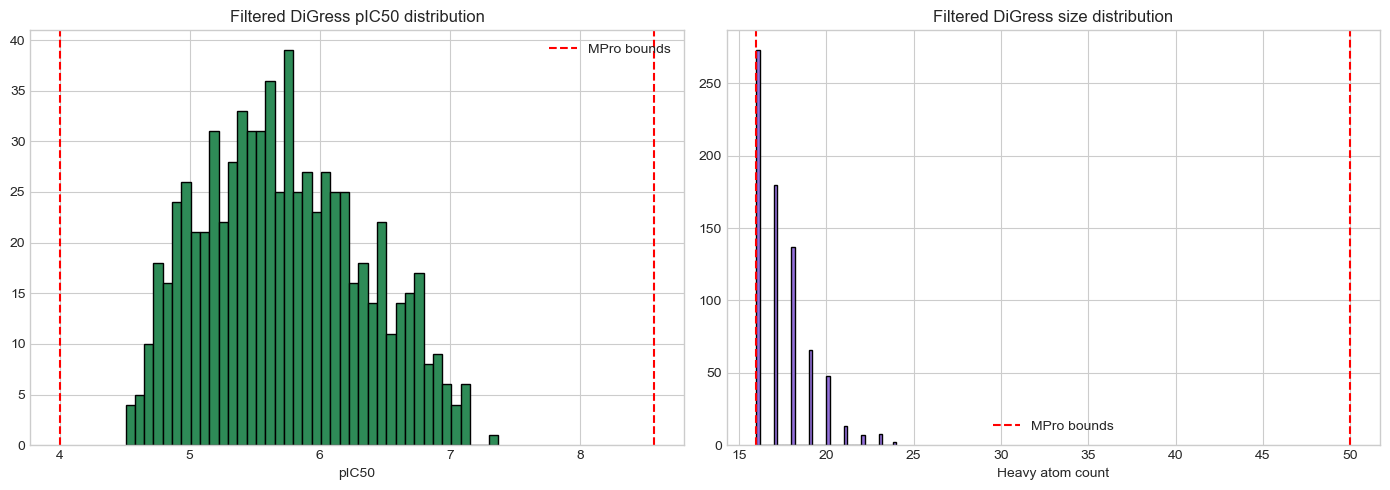

In [7]:
for csv_path in [EXTERNAL_CSV_14, EXTERNAL_CSV_21]:
    if not csv_path.exists():
        raise FileNotFoundError(
            f'Missing external prediction CSV: {csv_path}\n'
            'Run the external inference cell in mpro_gine_pic50_regression.ipynb first.'
        )

# Load and concatenate both CSVs.
frame_14 = pd.read_csv(EXTERNAL_CSV_14)[['SMILES', 'pIC50']].copy()
frame_14['source'] = '14Apr2026'
frame_21 = pd.read_csv(EXTERNAL_CSV_21)[['SMILES', 'pIC50']].copy()
frame_21['source'] = '21Apr2026'

combined = pd.concat([frame_14, frame_21], ignore_index=True)
combined['SMILES'] = combined['SMILES'].fillna('').astype(str).str.strip()
combined['pIC50'] = pd.to_numeric(combined['pIC50'], errors='coerce')
combined = combined.loc[combined['SMILES'].ne('') & combined['pIC50'].notna()].copy()

# Deduplicate: average pIC50 for the same SMILES across sources.
n_before_dedup = len(combined)
combined = (
    combined.groupby('SMILES', as_index=False)
    .agg(pIC50=('pIC50', 'mean'), source=('source', lambda v: '|'.join(sorted(set(v)))))
    .reset_index(drop=True)
)
n_after_dedup = len(combined)

# Compute heavy atom count.
combined['heavy_atoms'] = combined['SMILES'].map(get_heavy_atom_count)
combined = combined.dropna(subset=['heavy_atoms']).copy()
combined['heavy_atoms'] = combined['heavy_atoms'].astype(int)

# Apply filters based on MPro bounds.
pic50_lo = MPRO_PIC50_MIN - PIC50_BUFFER
pic50_hi = MPRO_PIC50_MAX + PIC50_BUFFER
size_lo = MPRO_SIZE_MIN - SIZE_BUFFER
size_hi = MPRO_SIZE_MAX + SIZE_BUFFER

mask = (
    combined['pIC50'].between(pic50_lo, pic50_hi)
    & combined['heavy_atoms'].between(size_lo, size_hi)
)
filtered_digress = combined.loc[mask].reset_index(drop=True).copy()

display_key_values(
    'DiGress filtering summary',
    {
        'Rows from 14Apr2026 CSV': len(frame_14),
        'Rows from 21Apr2026 CSV': len(frame_21),
        'Rows after concat': n_before_dedup,
        'Rows after deduplication': n_after_dedup,
        'Rows with valid heavy atoms': len(combined),
        'pIC50 filter range': f'[{pic50_lo:.4f}, {pic50_hi:.4f}]',
        'Size filter range (heavy atoms)': f'[{size_lo}, {size_hi}]',
        'DiGress molecules passing filter': len(filtered_digress),
        'DiGress molecules excluded': n_after_dedup - len(filtered_digress),
    },
)

# Show pIC50 distribution of filtered pool.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(filtered_digress['pIC50'], bins=40, color='seagreen', edgecolor='black')
axes[0].axvline(pic50_lo, color='red', linestyle='--', label='MPro bounds')
axes[0].axvline(pic50_hi, color='red', linestyle='--')
axes[0].set_xlabel('pIC50')
axes[0].set_title('Filtered DiGress pIC50 distribution')
axes[0].legend()

axes[1].hist(filtered_digress['heavy_atoms'], bins=40, color='mediumpurple', edgecolor='black')
axes[1].axvline(size_lo, color='red', linestyle='--', label='MPro bounds')
axes[1].axvline(size_hi, color='red', linestyle='--')
axes[1].set_xlabel('Heavy atom count')
axes[1].set_title('Filtered DiGress size distribution')
axes[1].legend()

plt.tight_layout()
plt.show()


## Graph Featurization

Node and edge featurizer functions, graph builder, and the cached MPro graph objects. Identical featurization to the base notebook so models are directly comparable.


In [8]:
ATOM_TYPES = ['C', 'N', 'O', 'F', 'S', 'Cl', 'Br', 'I', 'P', 'H', 'Other']
ATOM_TO_INDEX = {symbol: idx for idx, symbol in enumerate(ATOM_TYPES)}
HYBRIDIZATION_TYPES = [
    Chem.rdchem.HybridizationType.SP,
    Chem.rdchem.HybridizationType.SP2,
    Chem.rdchem.HybridizationType.SP3,
    Chem.rdchem.HybridizationType.SP3D,
    Chem.rdchem.HybridizationType.SP3D2,
]
BOND_TYPES = [
    Chem.rdchem.BondType.SINGLE,
    Chem.rdchem.BondType.DOUBLE,
    Chem.rdchem.BondType.TRIPLE,
    Chem.rdchem.BondType.AROMATIC,
]
STEREO_TYPES = [
    Chem.rdchem.BondStereo.STEREONONE,
    Chem.rdchem.BondStereo.STEREOANY,
    Chem.rdchem.BondStereo.STEREOZ,
    Chem.rdchem.BondStereo.STEREOE,
]


def one_hot_with_unknown(value, choices):
    vector = [0.0] * (len(choices) + 1)
    try:
        vector[choices.index(value)] = 1.0
    except ValueError:
        vector[-1] = 1.0
    return vector


def atom_features(atom: Chem.Atom) -> torch.Tensor:
    symbol = atom.GetSymbol()
    symbol = symbol if symbol in ATOM_TO_INDEX else 'Other'
    feature_vector = []
    feature_vector.extend(one_hot_with_unknown(symbol, ATOM_TYPES[:-1]))
    feature_vector.extend(one_hot_with_unknown(atom.GetHybridization(), HYBRIDIZATION_TYPES))
    feature_vector.extend(one_hot_with_unknown(atom.GetDegree(), [0, 1, 2, 3, 4, 5]))
    feature_vector.extend(one_hot_with_unknown(atom.GetTotalNumHs(), [0, 1, 2, 3, 4]))
    feature_vector.extend(one_hot_with_unknown(atom.GetFormalCharge(), [-2, -1, 0, 1, 2]))
    feature_vector.extend([float(atom.GetIsAromatic()), float(atom.IsInRing()), float(atom.GetMass() / 200.0)])
    return torch.tensor(feature_vector, dtype=torch.float32)


def bond_features(bond: Chem.Bond) -> torch.Tensor:
    feature_vector = []
    feature_vector.extend(one_hot_with_unknown(bond.GetBondType(), BOND_TYPES))
    feature_vector.extend(one_hot_with_unknown(bond.GetStereo(), STEREO_TYPES))
    feature_vector.extend([float(bond.GetIsConjugated()), float(bond.IsInRing())])
    return torch.tensor(feature_vector, dtype=torch.float32)


EXAMPLE_BOND = Chem.MolFromSmiles('CC').GetBondWithIdx(0)
BOND_FEATURE_DIM = bond_features(EXAMPLE_BOND).numel()


def molecule_to_graph(smiles: str, target: float, pdb_id: str) -> Dict[str, torch.Tensor]:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f'RDKit could not parse SMILES for {pdb_id}: {smiles}')
    node_features = torch.stack([atom_features(atom) for atom in mol.GetAtoms()])
    edge_pairs, edge_features_list = [], []
    for bond in mol.GetBonds():
        s, e = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        feat = bond_features(bond)
        edge_pairs.extend([[s, e], [e, s]])
        edge_features_list.extend([feat, feat.clone()])
    if edge_pairs:
        edge_index = torch.tensor(edge_pairs, dtype=torch.long).t().contiguous()
        edge_attr = torch.stack(edge_features_list)
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
        edge_attr = torch.empty((0, BOND_FEATURE_DIM), dtype=torch.float32)
    return {
        'x': node_features,
        'edge_index': edge_index,
        'edge_attr': edge_attr,
        'y': torch.tensor(float(target), dtype=torch.float32),
        'pdb_id': pdb_id,
        'smiles': smiles,
    }


def read_smiles_from_smi(pdb_id: str, smi_dir: Path) -> str:
    matches = sorted(smi_dir.glob(f'{pdb_id}_*.smi'))
    if not matches:
        raise FileNotFoundError(f'No .smi file found for {pdb_id}')
    with matches[0].open('r', encoding='utf-8') as handle:
        line = handle.readline().strip()
    if not line:
        raise ValueError(f'Empty .smi file for {pdb_id}: {matches[0]}')
    return line.split()[0]


def build_graph_cache(force_rebuild: bool = False) -> Dict[str, List[Dict[str, torch.Tensor]]]:
    if GRAPH_CACHE.exists() and not force_rebuild:
        print(f'Loading cached graphs from: {GRAPH_CACHE}')
        return torch.load(GRAPH_CACHE, weights_only=False)
    print('Cache miss or forced rebuild. Recomputing graph tensors...')
    split_files = {'train': TRAIN_CSV, 'val': VAL_CSV, 'test': TEST_CSV}
    cache = {}
    for split_name, csv_path in split_files.items():
        frame = pd.read_csv(csv_path).copy()
        frame['smiles_from_smi'] = frame['PDB_ID'].map(lambda pid: read_smiles_from_smi(pid, SMI_DIR))
        graphs = [molecule_to_graph(row.smiles_from_smi, row.pIC50, row.PDB_ID) for row in frame.itertuples(index=False)]
        cache[split_name] = graphs
    torch.save(cache, GRAPH_CACHE)
    print(f'Graph cache saved to: {GRAPH_CACHE}')
    return cache


GRAPH_CACHE_CONTENT = build_graph_cache(force_rebuild=FORCE_REBUILD_GRAPHS)

display_key_values(
    'Graph cache summary',
    {
        'Train graphs (original)': len(GRAPH_CACHE_CONTENT['train']),
        'Val graphs': len(GRAPH_CACHE_CONTENT['val']),
        'Test graphs': len(GRAPH_CACHE_CONTENT['test']),
        'Node feature dim': int(GRAPH_CACHE_CONTENT['train'][0]['x'].shape[-1]),
        'Edge feature dim': int(GRAPH_CACHE_CONTENT['train'][0]['edge_attr'].shape[-1]),
    },
)


Loading cached graphs from: C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMProURV\notebooks\mpro_gine_regression\artifacts\mpro_graph_cache.pt

Graph cache summary


,value
Train graphs (original),210
Val graphs,50
Test graphs,64
Node feature dim,39
Edge feature dim,12


## Step 3 — Construct Configurable Augmented Training Split

The augmented training split is built as follows:

1. Start with **all MPro train molecules** (graphs already in cache).
2. Convert the filtered DiGress molecules to graphs.
3. Choose `DIGRESS_APPEND_PERCENT`, interpreted as a percentage of the MPro train size.
4. Randomly sample `N = ceil(len(mpro_train) * DIGRESS_APPEND_PERCENT / 100)` molecules from the filtered DiGress pool.
5. If the filtered DiGress pool is smaller than the requested size, use the full available pool.
6. Concatenate: `augmented_train = mpro_train + digress_sample`.

Validation and test splits remain exactly as in the original cache.


In [9]:
# Control how many DiGress molecules are appended relative to the MPro train split.

if not 1 <= int(DIGRESS_APPEND_PERCENT) <= 100:
    raise ValueError('DIGRESS_APPEND_PERCENT must be an integer between 1 and 100.')

DIGRESS_APPEND_PERCENT = int(DIGRESS_APPEND_PERCENT)
display_key_values(
    'DiGress augmentation ratio control',
    {
        'DIGRESS_APPEND_PERCENT': DIGRESS_APPEND_PERCENT,
        'Meaning': 'Percent of the original MPro train size to append from the filtered DiGress pool',
    },
)


DiGress augmentation ratio control


,value
DIGRESS_APPEND_PERCENT,50
Meaning,Percent of the original MPro train size to app...


In [10]:
# Convert filtered DiGress molecules to graphs.
digress_graphs = []
failed_smiles = []
for row_idx, row in filtered_digress.iterrows():
    try:
        g = molecule_to_graph(
            smiles=str(row['SMILES']),
            target=float(row['pIC50']),
            pdb_id=f"digress_{row['source']}_{row_idx:05d}",
        )
        digress_graphs.append(g)
    except ValueError:
        failed_smiles.append(row['SMILES'])

if failed_smiles:
    print(f'Warning: {len(failed_smiles)} filtered DiGress SMILES failed RDKit parsing and were skipped.')

print(f'Filtered DiGress graphs available for sampling: {len(digress_graphs)}')

# Sample a user-controlled percentage of the MPro train size from the filtered DiGress pool.
ORIGINAL_TRAIN_GRAPHS = list(GRAPH_CACHE_CONTENT['train'])
N_MPRO_TRAIN = len(ORIGINAL_TRAIN_GRAPHS)
REQUESTED_N_SAMPLE = max(1, math.ceil(N_MPRO_TRAIN * DIGRESS_APPEND_PERCENT / 100.0))
N_SAMPLE = min(REQUESTED_N_SAMPLE, len(digress_graphs))
if N_SAMPLE < REQUESTED_N_SAMPLE:
    print(
        f'Requested {REQUESTED_N_SAMPLE} DiGress molecules from DIGRESS_APPEND_PERCENT={DIGRESS_APPEND_PERCENT}, '
        f'but only {len(digress_graphs)} are available after filtering. Using the full available pool.'
    )

rng = random.Random(SEED)
digress_sample = rng.sample(digress_graphs, N_SAMPLE)

AUGMENTED_TRAIN_GRAPHS = ORIGINAL_TRAIN_GRAPHS + digress_sample

# Compute normalization statistics from the augmented training split only.
train_targets_raw = np.array([g['y'].item() for g in AUGMENTED_TRAIN_GRAPHS], dtype=np.float32)
TARGET_MEAN = float(train_targets_raw.mean())
TARGET_STD = float(train_targets_raw.std())
if TARGET_STD <= 1e-8:
    TARGET_STD = 1.0

NODE_DIM = int(AUGMENTED_TRAIN_GRAPHS[0]['x'].shape[-1])
EDGE_DIM = int(AUGMENTED_TRAIN_GRAPHS[0]['edge_attr'].shape[-1])

# Build the final split dictionary used by data loaders.
SPLITS = {
    'train': AUGMENTED_TRAIN_GRAPHS,
    'val': GRAPH_CACHE_CONTENT['val'],
    'test': GRAPH_CACHE_CONTENT['test'],
}

display_key_values(
    'Augmented split summary',
    {
        'MPro train molecules': N_MPRO_TRAIN,
        'Requested DiGress append percent': DIGRESS_APPEND_PERCENT,
        'Filtered DiGress pool size': len(digress_graphs),
        'Requested DiGress sample size': REQUESTED_N_SAMPLE,
        'DiGress molecules sampled': N_SAMPLE,
        'Augmented train size': len(AUGMENTED_TRAIN_GRAPHS),
        'DiGress share of augmented train (%)': round(100.0 * N_SAMPLE / len(AUGMENTED_TRAIN_GRAPHS), 2),
        'Val size': len(SPLITS['val']),
        'Test size': len(SPLITS['test']),
        'Node feature dim': NODE_DIM,
        'Edge feature dim': EDGE_DIM,
        'TARGET_MEAN (train)': round(TARGET_MEAN, 4),
        'TARGET_STD (train)': round(TARGET_STD, 4),
    },
)

# Split pIC50 overview.
split_rows = []
for split_name, graphs in SPLITS.items():
    vals = np.array([g['y'].item() for g in graphs], dtype=np.float32)
    label = 'train_augmented' if split_name == 'train' else split_name
    split_rows.append({'split': label, 'n': len(graphs), 'mean': vals.mean(), 'std': vals.std(), 'min': vals.min(), 'max': vals.max()})
print_banner('Split pIC50 statistics')
display(pd.DataFrame(split_rows).round(4))


Filtered DiGress graphs available for sampling: 734

Augmented split summary


,value
MPro train molecules,210
Requested DiGress append percent,50
Filtered DiGress pool size,734
Requested DiGress sample size,105
DiGress molecules sampled,105
Augmented train size,315
DiGress share of augmented train (%),33.33
Val size,50
Test size,64
Node feature dim,39



Split pIC50 statistics


,split,n,mean,std,min,max
0,train_augmented,315,5.8717,0.9087,4.0185,8.5686
1,val,50,5.7440,0.8914,4.0042,7.6990
2,test,64,5.8955,0.7960,4.0135,8.0000


## Dataset, Data Loaders, and Batch Validation

Wrap graphs into a PyTorch dataset with target normalization, then verify one mini-batch has the expected tensor shapes.


In [11]:
class MoleculeGraphDataset(Dataset):
    def __init__(self, graphs, y_mean=None, y_std=None):
        self.graphs = graphs
        self.y_mean = y_mean
        self.y_std = y_std

    def __len__(self):
        return len(self.graphs)

    def __getitem__(self, idx):
        item = self.graphs[idx]
        y = item['y']
        if self.y_mean is not None and self.y_std is not None:
            y = (y - self.y_mean) / self.y_std
        return {
            'x': item['x'],
            'edge_index': item['edge_index'],
            'edge_attr': item['edge_attr'],
            'y': y,
            'y_raw': item['y'],
            'pdb_id': item['pdb_id'],
            'smiles': item['smiles'],
        }


def collate_graphs(batch):
    x_parts, edge_index_parts, edge_attr_parts, batch_index = [], [], [], []
    targets, raw_targets, pdb_ids, smiles_list = [], [], [], []
    node_offset = 0
    for graph_idx, item in enumerate(batch):
        num_nodes = item['x'].size(0)
        x_parts.append(item['x'])
        batch_index.append(torch.full((num_nodes,), graph_idx, dtype=torch.long))
        targets.append(item['y'].view(1))
        raw_targets.append(item['y_raw'].view(1))
        pdb_ids.append(item['pdb_id'])
        smiles_list.append(item['smiles'])
        if item['edge_index'].numel() > 0:
            edge_index_parts.append(item['edge_index'] + node_offset)
            edge_attr_parts.append(item['edge_attr'])
        node_offset += num_nodes
    edge_dim = batch[0]['edge_attr'].size(-1) if batch[0]['edge_attr'].ndim == 2 else 0
    return {
        'x': torch.cat(x_parts, dim=0),
        'edge_index': torch.cat(edge_index_parts, dim=1) if edge_index_parts else torch.empty((2, 0), dtype=torch.long),
        'edge_attr': torch.cat(edge_attr_parts, dim=0) if edge_attr_parts else torch.empty((0, edge_dim), dtype=torch.float32),
        'batch': torch.cat(batch_index, dim=0),
        'y': torch.cat(targets, dim=0),
        'y_raw': torch.cat(raw_targets, dim=0),
        'pdb_id': pdb_ids,
        'smiles': smiles_list,
    }


def move_batch_to_device(batch, device):
    tensor_keys = {'x', 'edge_index', 'edge_attr', 'batch', 'y', 'y_raw'}
    return {k: v.to(device) if k in tensor_keys else v for k, v in batch.items()}


def build_data_loaders(batch_size: int):
    train_ds = MoleculeGraphDataset(SPLITS['train'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    val_ds = MoleculeGraphDataset(SPLITS['val'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    test_ds = MoleculeGraphDataset(SPLITS['test'], y_mean=TARGET_MEAN, y_std=TARGET_STD)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_graphs)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_graphs)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_graphs)
    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = build_data_loaders(BASE_TRAINING_CONFIG['batch_size'])
sample_batch = next(iter(train_loader))
display_key_values('Mini-batch sanity check', {
    'Node feature tensor': tuple(sample_batch['x'].shape),
    'Edge index tensor': tuple(sample_batch['edge_index'].shape),
    'Edge attribute tensor': tuple(sample_batch['edge_attr'].shape),
    'Batch index tensor': tuple(sample_batch['batch'].shape),
    'Target tensor': tuple(sample_batch['y'].shape),
    'Unique molecules': len(sample_batch['pdb_id']),
})



Mini-batch sanity check


,value
Node feature tensor,"(3237, 39)"
Edge index tensor,"(2, 7064)"
Edge attribute tensor,"(7064, 12)"
Batch index tensor,"(3237,)"
Target tensor,"(128,)"
Unique molecules,128


## GINE Regressor Model


In [12]:
class FeedForward(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.net(x)


class GINELayer(nn.Module):
    def __init__(self, hidden_dim, dropout):
        super().__init__()
        self.edge_encoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Linear(hidden_dim, hidden_dim)
        )
        self.update_mlp = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, hidden_dim)
        )
        self.norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.eps = nn.Parameter(torch.zeros(1))

    def forward(self, x, edge_index, edge_attr):
        if edge_index.numel() == 0:
            return self.norm(x + self.dropout(self.update_mlp((1.0 + self.eps) * x)))
        src, dst = edge_index
        messages = F.relu(x[src] + self.edge_encoder(edge_attr))
        aggregated = torch.zeros_like(x)
        aggregated.index_add_(0, dst, messages)
        updated = self.update_mlp((1.0 + self.eps) * x + aggregated)
        return self.norm(x + self.dropout(updated))


def global_mean_pool(x, batch):
    num_graphs = int(batch.max().item()) + 1
    pooled = torch.zeros((num_graphs, x.size(-1)), device=x.device)
    counts = torch.zeros(num_graphs, device=x.device)
    pooled.index_add_(0, batch, x)
    counts.index_add_(0, batch, torch.ones_like(batch, dtype=x.dtype))
    return pooled / counts.clamp_min(1.0).unsqueeze(-1)


def global_max_pool(x, batch):
    num_graphs = int(batch.max().item()) + 1
    return torch.stack([x[batch == i].max(dim=0).values for i in range(num_graphs)])


class GINERegressor(nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.node_encoder = nn.Linear(node_dim, hidden_dim)
        self.edge_input = nn.Linear(edge_dim, hidden_dim)
        self.layers = nn.ModuleList([GINELayer(hidden_dim, dropout) for _ in range(num_layers)])
        self.readout = FeedForward(hidden_dim * 2, hidden_dim, hidden_dim, dropout)
        self.output_head = nn.Sequential(nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim, 1))

    def forward(self, batch):
        x = self.node_encoder(batch['x'])
        edge_attr = self.edge_input(batch['edge_attr'])
        for layer in self.layers:
            x = layer(x, batch['edge_index'], edge_attr)
        pooled = torch.cat([global_mean_pool(x, batch['batch']), global_max_pool(x, batch['batch'])], dim=-1)
        return self.output_head(self.readout(pooled)).squeeze(-1)


def normalize_model_config(model_config=None):
    cfg = dict(BASE_MODEL_CONFIG)
    if model_config:
        cfg.update(model_config)
    return {'hidden_dim': int(cfg['hidden_dim']), 'num_layers': int(cfg['num_layers']), 'dropout': float(cfg['dropout'])}


def normalize_training_config(training_config=None):
    cfg = dict(BASE_TRAINING_CONFIG)
    if training_config:
        cfg.update(training_config)
    return {
        'batch_size': int(cfg['batch_size']),
        'learning_rate': float(cfg['learning_rate']),
        'weight_decay': float(cfg['weight_decay']),
        'max_epochs': int(cfg['max_epochs']),
        'patience': int(cfg['patience']),
        'loss_name': str(cfg['loss_name']).lower(),
    }


def instantiate_model(model_config=None):
    cfg = normalize_model_config(model_config)
    return GINERegressor(
        node_dim=NODE_DIM, edge_dim=EDGE_DIM,
        hidden_dim=cfg['hidden_dim'], num_layers=cfg['num_layers'], dropout=cfg['dropout']
    ).to(DEVICE)


def count_trainable_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model = instantiate_model()
display_key_values('Model summary', {
    'Model class': model.__class__.__name__,
    'Hidden dim': BASE_MODEL_CONFIG['hidden_dim'],
    'GINE layers': BASE_MODEL_CONFIG['num_layers'],
    'Dropout': BASE_MODEL_CONFIG['dropout'],
    'Trainable parameters': count_trainable_parameters(model),
})



Model summary


,value
Model class,GINERegressor
Hidden dim,256
GINE layers,6
Dropout,0.05
Trainable parameters,1793031


## Training Helpers


In [13]:
def compute_regression_loss(prediction, target, loss_name='rmse', eps=1e-8):
    if loss_name == 'rmse':
        return torch.sqrt(F.mse_loss(prediction, target) + eps)
    if loss_name == 'mse':
        return F.mse_loss(prediction, target)
    raise ValueError(f'Unsupported loss_name: {loss_name}')


@torch.no_grad()
def evaluate_regression(model, loader):
    model.eval()
    predictions, targets, pdb_ids, smiles_list = [], [], [], []
    for batch in loader:
        batch = move_batch_to_device(batch, DEVICE)
        pred_norm = model(batch).detach().cpu().numpy()
        prediction = pred_norm * TARGET_STD + TARGET_MEAN
        predictions.append(prediction)
        targets.append(batch['y_raw'].detach().cpu().numpy())
        pdb_ids.extend(batch['pdb_id'])
        smiles_list.extend(batch['smiles'])
    predictions = np.concatenate(predictions)
    targets = np.concatenate(targets)
    rmse = math.sqrt(mean_squared_error(targets, predictions))
    r2 = r2_score(targets, predictions)
    pearson = pearsonr(targets, predictions).statistic if len(targets) > 1 else float('nan')
    return {'predictions': predictions, 'targets': targets, 'rmse': rmse, 'r2': r2, 'pearson': pearson,
            'pdb_id': np.array(pdb_ids), 'smiles': np.array(smiles_list)}


def fit_regressor(model, train_loader, val_loader, test_loader=None,
                  model_config=None, training_config=None,
                  checkpoint_path=None, history_path=None, verbose=True):
    resolved_model_config = normalize_model_config(model_config)
    resolved_training_config = normalize_training_config(training_config)
    loss_name = resolved_training_config['loss_name']

    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=resolved_training_config['learning_rate'],
                                  weight_decay=resolved_training_config['weight_decay'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=6)

    history = {k: [] for k in ['train_loss', 'train_rmse', 'train_r2', 'train_pearson',
                                'val_rmse', 'val_r2', 'val_pearson',
                                'test_rmse', 'test_r2', 'test_pearson']}
    best_state = best_metrics = None
    best_rmse = float('inf')
    best_epoch = patience_counter = 0

    for epoch in range(1, resolved_training_config['max_epochs'] + 1):
        model.train()
        running_loss = sample_count = 0
        for batch in train_loader:
            batch = move_batch_to_device(batch, DEVICE)
            optimizer.zero_grad()
            loss = compute_regression_loss(model(batch), batch['y'], loss_name=loss_name)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            running_loss += loss.item() * batch['y'].size(0)
            sample_count += batch['y'].size(0)

        train_loss = running_loss / max(sample_count, 1)
        train_m = evaluate_regression(model, train_loader)
        val_m = evaluate_regression(model, val_loader)
        test_m = evaluate_regression(model, test_loader) if test_loader else None
        scheduler.step(val_m['rmse'])

        for key, val in [('train_loss', train_loss), ('train_rmse', train_m['rmse']),
                         ('train_r2', train_m['r2']), ('train_pearson', train_m['pearson']),
                         ('val_rmse', val_m['rmse']), ('val_r2', val_m['r2']), ('val_pearson', val_m['pearson'])]:
            history[key].append(val)
        if test_m:
            for key in ['test_rmse', 'test_r2', 'test_pearson']:
                history[key].append(test_m[key.split('_')[1]])

        improved = val_m['rmse'] < best_rmse
        if improved:
            best_rmse = val_m['rmse']
            best_epoch = epoch
            patience_counter = 0
            best_state = copy.deepcopy(model.state_dict())
            best_metrics = {'rmse': float(val_m['rmse']), 'r2': float(val_m['r2']), 'pearson': float(val_m['pearson'])}
            if checkpoint_path:
                torch.save({'model_state': best_state,
                            'config': {'node_dim': NODE_DIM, 'edge_dim': EDGE_DIM,
                                       **resolved_model_config, **resolved_training_config,
                                       'active_threshold': ACTIVE_THRESHOLD, 'seed': SEED},
                            'target_mean': TARGET_MEAN, 'target_std': TARGET_STD,
                            'best_epoch': best_epoch, 'best_val_rmse': best_rmse}, checkpoint_path)
        else:
            patience_counter += 1

        if verbose:
            lr = optimizer.param_groups[0]['lr']
            parts = [f'Epoch {epoch:03d}', f'lr={lr:.2e}', f'{loss_name}={train_loss:.4f}',
                     f"train_rmse={train_m['rmse']:.4f}", f"val_rmse={val_m['rmse']:.4f}",
                     f"val_r2={val_m['r2']:.4f}"]
            if test_m:
                parts.append(f"test_rmse={test_m['rmse']:.4f}")
            if improved:
                parts.append('status=best_checkpoint')
            print(' | '.join(parts))

        if patience_counter >= resolved_training_config['patience']:
            if verbose:
                print(f'Early stopping at epoch {epoch}. Best epoch: {best_epoch}')
            break

    if best_state is None:
        raise RuntimeError('Training finished without producing a valid checkpoint.')
    model.load_state_dict(best_state)
    if history_path:
        with history_path.open('w', encoding='utf-8') as fh:
            json.dump(history, fh, indent=2)
    return {'history': history, 'loss_name': loss_name, 'model_config': resolved_model_config,
            'training_config': resolved_training_config, 'best_epoch': best_epoch,
            'best_val_rmse': best_metrics['rmse'], 'best_val_r2': best_metrics['r2'],
            'best_val_pearson': best_metrics['pearson']}


def history_to_frame(history):
    return pd.DataFrame(history)


def plot_training_history(history_frame, loss_name='train_loss'):
    _, axes = plt.subplots(2, 2, figsize=(18, 10))
    axes = axes.ravel()
    axes[0].plot(history_frame['train_loss'], label=f'Train {loss_name.upper()}')
    axes[0].set_title(f'Optimization Loss ({loss_name.upper()})')
    axes[0].legend()
    axes[1].plot(history_frame['train_rmse'], label='Train RMSE')
    axes[1].plot(history_frame['val_rmse'], label='Val RMSE')
    if 'test_rmse' in history_frame and len(history_frame['test_rmse'].dropna()):
        axes[1].plot(history_frame['test_rmse'], label='Test RMSE')
    axes[1].set_title('RMSE')
    axes[1].legend()
    axes[2].plot(history_frame['train_r2'], label='Train R²')
    axes[2].plot(history_frame['val_r2'], label='Val R²')
    if 'test_r2' in history_frame and len(history_frame['test_r2'].dropna()):
        axes[2].plot(history_frame['test_r2'], label='Test R²')
    axes[2].set_title('R²')
    axes[2].legend()
    axes[3].plot(history_frame['train_pearson'], label='Train Pearson')
    axes[3].plot(history_frame['val_pearson'], label='Val Pearson')
    if 'test_pearson' in history_frame and len(history_frame['test_pearson'].dropna()):
        axes[3].plot(history_frame['test_pearson'], label='Test Pearson')
    axes[3].set_title('Pearson Correlation')
    axes[3].legend()
    plt.tight_layout()
    plt.show()


## Training Cell

Train the GINE regressor on the configurable filtered augmentation. The best validation checkpoint is saved automatically.



Final training run — configurable filtered DiGress augmentation


,group,name,value
0,model,hidden_dim,256
1,model,num_layers,6
2,model,dropout,0.05
3,training,batch_size,128
4,training,learning_rate,0.0005
5,training,weight_decay,0.00001
6,training,max_epochs,300
7,training,patience,50
8,training,loss_name,rmse
9,data,mpro_train,210


Epoch 001 | lr=5.00e-04 | rmse=1.0388 | train_rmse=0.9183 | val_rmse=0.9363 | val_r2=-0.1035 | test_rmse=0.8074 | status=best_checkpoint
Epoch 002 | lr=5.00e-04 | rmse=1.0089 | train_rmse=0.9087 | val_rmse=0.8946 | val_r2=-0.0072 | test_rmse=0.7983 | status=best_checkpoint
Epoch 003 | lr=5.00e-04 | rmse=0.9944 | train_rmse=0.9171 | val_rmse=0.8899 | val_r2=0.0033 | test_rmse=0.8108 | status=best_checkpoint
Epoch 004 | lr=5.00e-04 | rmse=0.9979 | train_rmse=0.9040 | val_rmse=0.8946 | val_r2=-0.0072 | test_rmse=0.7939
Epoch 005 | lr=5.00e-04 | rmse=0.9930 | train_rmse=0.9049 | val_rmse=0.8893 | val_r2=0.0047 | test_rmse=0.7976 | status=best_checkpoint
Epoch 006 | lr=5.00e-04 | rmse=0.9829 | train_rmse=0.9289 | val_rmse=0.8920 | val_r2=-0.0014 | test_rmse=0.8293
Epoch 007 | lr=5.00e-04 | rmse=0.9903 | train_rmse=0.9177 | val_rmse=0.8869 | val_r2=0.0100 | test_rmse=0.8191 | status=best_checkpoint
Epoch 008 | lr=5.00e-04 | rmse=0.9747 | train_rmse=0.9179 | val_rmse=0.8867 | val_r2=0.0104 | 

,value
Best epoch,10
Validation RMSE,0.865
Validation R²,0.0583
Validation Pearson,0.2801
Checkpoint path,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...


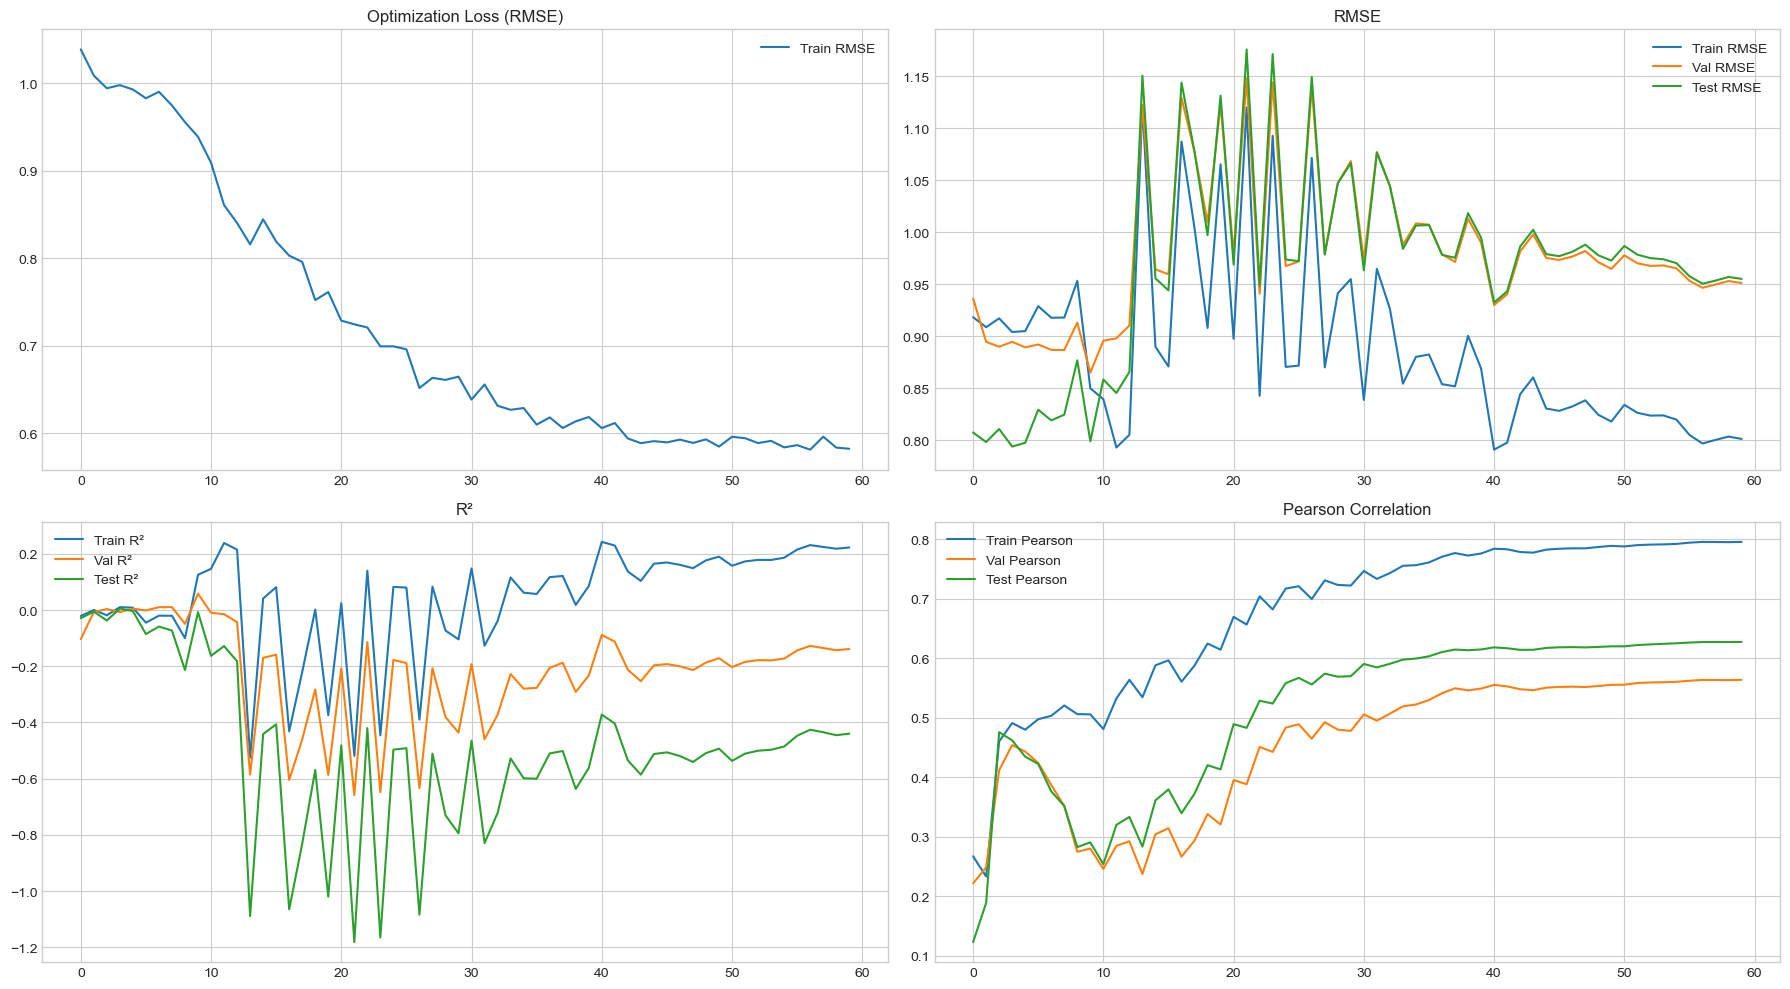

,train_loss,train_rmse,train_r2,train_pearson,val_rmse,val_r2,val_pearson,test_rmse,test_r2,test_pearson
55,0.5864,0.8051,0.2150,0.7942,0.9533,-0.1439,0.5621,0.9576,-0.4472,0.6263
56,0.5812,0.7969,0.2309,0.7954,0.9465,-0.1276,0.5634,0.9505,-0.4258,0.6271
57,0.5960,0.8003,0.2242,0.7953,0.9497,-0.1352,0.5634,0.9534,-0.4347,0.6273
58,0.5836,0.8035,0.2181,0.7950,0.9530,-0.1431,0.5632,0.9569,-0.4453,0.6271
59,0.5822,0.8013,0.2224,0.7955,0.9511,-0.1386,0.5636,0.9551,-0.4397,0.6273


In [14]:
selected_model_config = normalize_model_config()
selected_training_config = normalize_training_config()

print_banner('Final training run — configurable filtered DiGress augmentation')
display(pd.DataFrame(
    [{'group': 'model', 'name': k, 'value': v} for k, v in selected_model_config.items()]
    + [{'group': 'training', 'name': k, 'value': v} for k, v in selected_training_config.items()]
    + [
        {'group': 'data', 'name': 'mpro_train', 'value': N_MPRO_TRAIN},
        {'group': 'data', 'name': 'digress_filtered_pool', 'value': len(digress_graphs)},
        {'group': 'data', 'name': 'digress_sampled', 'value': N_SAMPLE},
        {'group': 'data', 'name': 'augmented_train_total', 'value': len(AUGMENTED_TRAIN_GRAPHS)},
    ]
))

train_loader, val_loader, test_loader = build_data_loaders(selected_training_config['batch_size'])
model = instantiate_model(selected_model_config)
training_result = fit_regressor(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    model_config=selected_model_config,
    training_config=selected_training_config,
    checkpoint_path=CHECKPOINT_PATH,
    history_path=HISTORY_PATH,
    verbose=True,
)

history_frame = history_to_frame(training_result['history'])
display_key_values('Best validation checkpoint', {
    'Best epoch': training_result['best_epoch'],
    'Validation RMSE': round(training_result['best_val_rmse'], 4),
    'Validation R²': round(training_result['best_val_r2'], 4),
    'Validation Pearson': round(training_result['best_val_pearson'], 4),
    'Checkpoint path': CHECKPOINT_PATH,
})

plot_training_history(history_frame, loss_name=training_result['loss_name'])
display(history_frame.tail().round(4))


## Test Set Predictions and Metrics


In [15]:
_, _, pred_test_loader = build_data_loaders(selected_training_config['batch_size'])
test_results = evaluate_regression(model, pred_test_loader)

predictions_frame = pd.DataFrame({
    'PDB_ID': test_results['pdb_id'],
    'SMILES': test_results['smiles'],
    'pIC50_real': test_results['targets'],
    'pIC50_predicted': test_results['predictions'],
})
predictions_frame['absolute_error'] = (predictions_frame['pIC50_real'] - predictions_frame['pIC50_predicted']).abs()
predictions_frame.to_csv(PREDICTIONS_PATH, index=False)

display_key_values('Test set summary', {
    'Test RMSE': round(test_results['rmse'], 4),
    'Test R²': round(test_results['r2'], 4),
    'Test Pearson': round(test_results['pearson'], 4),
    'Predictions CSV': PREDICTIONS_PATH,
})
display(predictions_frame.head().round(4))



Test set summary


,value
Test RMSE,0.799
Test R²,-0.0076
Test Pearson,0.2905
Predictions CSV,C:\Users\xaviv\URV\.MESIIA\TFM\repo\DiGressMPr...


,PDB_ID,SMILES,pIC50_real,pIC50_predicted,absolute_error
0,5RH3,Cc1ccncc1NC(=O)[C@H](C)c2cccc(c2)Cl,4.5817,5.5215,0.9398
1,7GBV,Cc1ccncc1NC(=O)C(C)(C)c2cccc(c2)Cl,4.0135,5.5762,1.5628
2,7GBX,c1ccc2c(c1)ncn2NC(=O)Cc3cccc(c3)Cl,5.0807,5.5121,0.4313
3,7GCV,Cc1ccncc1NC(=O)Cc2cc(cc(c2)Cl)O[C@@H]3CC(=O)N3,5.4402,5.5638,0.1236
4,7GD5,CN(C)c1ccc(cc1)N(Cc2ccsc2)C(=O)Cn3c4ccccc4nn3,5.7462,5.5935,0.1528


## ROC/AUC and Predicted vs Real pIC50



Test-set metrics


,metric,value
0,Pearson,0.2905
1,RMSE,0.7990
2,R2,-0.0076
3,ROC_AUC,0.6778



Activity class balance


,class,count
0,inactive,35
1,active,29


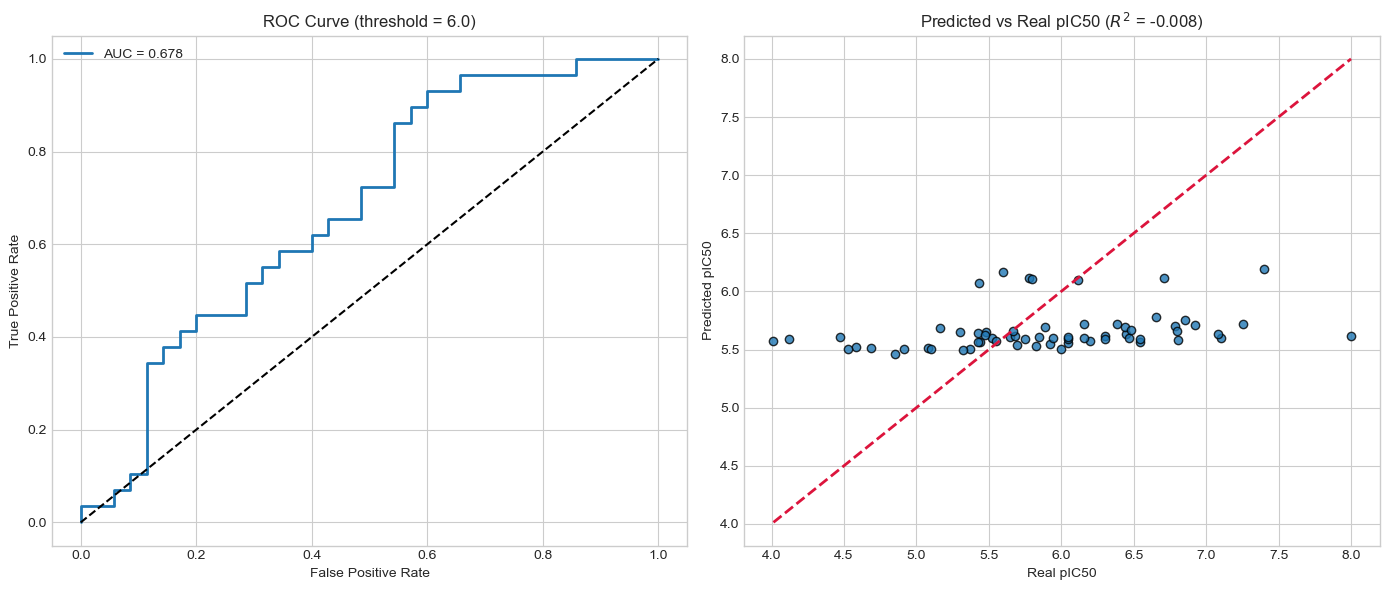


Largest test-set errors


,PDB_ID,SMILES,pIC50_real,pIC50_predicted,absolute_error
61,8UDO,CN(C)CCCCCNC(=O)C[C@H](Cc1ccc(cc1)F)NC(=O)[C@@...,8.0000,5.6187,2.3813
1,7GBV,Cc1ccncc1NC(=O)C(C)(C)c2cccc(c2)Cl,4.0135,5.5762,1.5628
52,7GN9,CNC(=O)C1(CC1)N2C[C@H](c3cc(ccc3C2=O)Cl)C(=O)N...,7.2570,5.7228,1.5342
36,7GKV,CNC(=O)CN1Cc2ccc(cc2[C@@H](C1)C(=O)Nc3cncc4c3c...,7.1026,5.5957,1.5069
9,7GEZ,CC(=O)N1CCN(CC1)CC(=O)Nc2cncc3c2cccc3,4.1216,5.5942,1.4726
39,7GLD,c1ccc2c(c1)cncc2NC(=O)[C@@H]3CN(Cc4c3cc(cc4)Cl...,7.0789,5.6345,1.4444
30,7GJM,C[C@H]1COc2ccc(cc2[C@@H]1C(=O)Nc3cncc4c3cccc4)Cl,6.8048,5.5783,1.2266
45,7GMG,CNC(=O)CN1C[C@H](c2cc(ccc2C1=O)Cl)C(=O)Nc3cncc...,6.9224,5.7103,1.2120
48,7GMS,CS(=O)(=O)Nc1ccc2c(c1)cncc2NC(=O)[C@@H]3CN(Cc4...,7.4021,6.1941,1.2081
63,9HAJ,CCc1cc(ccc1CN2CCN(CC[C@@H]2C(=O)NCC)C(=O)c3cc(...,6.7959,5.6616,1.1343


In [16]:
y_true = test_results['targets']
y_pred = test_results['predictions']

binary_true = (y_true >= ACTIVE_THRESHOLD).astype(int)
if np.unique(binary_true).size < 2:
    raise ValueError('ROC/AUC requires both classes in the test set for the chosen threshold.')

fpr, tpr, _ = roc_curve(binary_true, y_pred)
auc_value = roc_auc_score(binary_true, y_pred)

print_banner('Test-set metrics')
display(pd.DataFrame({
    'metric': ['Pearson', 'RMSE', 'R2', 'ROC_AUC'],
    'value': [test_results['pearson'], test_results['rmse'], test_results['r2'], auc_value],
}).round(4))

print_banner('Activity class balance')
display(pd.DataFrame({'class': ['inactive', 'active'], 'count': [(binary_true == 0).sum(), (binary_true == 1).sum()]}))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC curve
axes[0].plot(fpr, tpr, label=f'AUC = {auc_value:.3f}', linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve (threshold = {ACTIVE_THRESHOLD})')
axes[0].legend()

# Predicted vs real scatter
axes[1].scatter(y_true, y_pred, alpha=0.8, edgecolor='black')
lo, hi = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
axes[1].plot([lo, hi], [lo, hi], linestyle='--', color='crimson', linewidth=2)
axes[1].set_xlabel('Real pIC50')
axes[1].set_ylabel('Predicted pIC50')
axes[1].set_title(f'Predicted vs Real pIC50 ($R^2$ = {test_results["r2"]:.3f})')
axes[1].set_xlim(lo - 0.2, hi + 0.2)
axes[1].set_ylim(lo - 0.2, hi + 0.2)

plt.tight_layout()
plt.show()

print_banner('Largest test-set errors')
display(predictions_frame.sort_values('absolute_error', ascending=False).head(10).round(4))


## Multi-Seed Evaluation (Seeds 42–46)

GINE 1 (seed 42) is reused from the training cell above. Seeds 43–46 are trained here from scratch with the same architecture and hyperparameters, each with a different random seed controlling both the DiGress sample selection and the model weight initialization. The DiGress sample size follows the same `DIGRESS_APPEND_PERCENT` ratio used above. After all five runs, a summary table shows per-GINE test metrics together with the mean and standard deviation across runs. The plots shown are for the **best-performing GINE** (lowest test RMSE).


[19:35:59] GINE 1 (seed=42) — reused  |  RMSE=0.7990  |  Pearson=0.2905
[19:39:54] GINE 2 (seed=43) trained  |  best_epoch=43  |  RMSE=0.7287  |  Pearson=0.6522
[19:43:30] GINE 3 (seed=44) trained  |  best_epoch=38  |  RMSE=0.7377  |  Pearson=0.6408
[19:47:02] GINE 4 (seed=45) trained  |  best_epoch=41  |  RMSE=0.8604  |  Pearson=0.6534
[19:49:57] GINE 5 (seed=46) trained  |  best_epoch=44  |  RMSE=0.7443  |  Pearson=0.6163

Multi-seed evaluation summary  (5 runs, seeds 42–46)


,GINE,RMSE,Pearson,R²,Best Epoch
0,GINE 1 (seed=42),0.7990,0.2905,-0.0076,10
1,GINE 2 (seed=43),0.7287,0.6522,0.1619,43
2,GINE 3 (seed=44),0.7377,0.6408,0.1410,38
3,GINE 4 (seed=45),0.8604,0.6534,-0.1683,41
4,GINE 5 (seed=46),0.7443,0.6163,0.1256,44
5,Mean,0.7740,0.5706,0.0505,—
6,Std Dev,0.0555,0.1573,0.1392,—


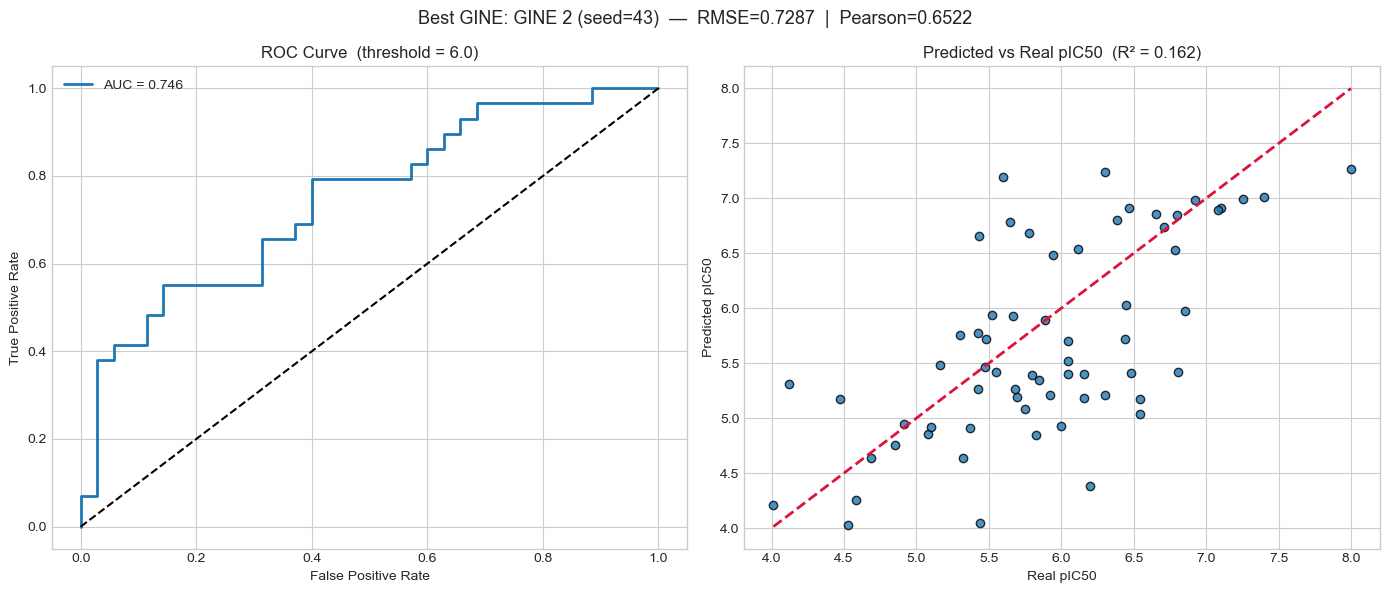

In [17]:

# ---------------------------------------------------------------------------
# Collect GINE 1 (seed=42) — already trained and evaluated above.
# ---------------------------------------------------------------------------
all_run_results = {
    42: {
        'rmse': test_results['rmse'],
        'pearson': test_results['pearson'],
        'r2': test_results['r2'],
        'pIC50_real': test_results['targets'],
        'pIC50_predicted': test_results['predictions'],
        'history': training_result['history'],
        'best_epoch': training_result['best_epoch'],
    }
}
ts0 = datetime.datetime.now().strftime('%H:%M:%S')
print(f"[{ts0}] GINE 1 (seed=42) — reused  |  RMSE={test_results['rmse']:.4f}  |  Pearson={test_results['pearson']:.4f}")

# ---------------------------------------------------------------------------
# Train GINEs 2–5 (seeds 43–46).
# Each run re-samples DIGRESS_APPEND_PERCENT % of MPro train from the
# filtered DiGress pool with its own seed and trains a fresh model.
# ---------------------------------------------------------------------------
for run_idx, seed in enumerate([43, 44, 45, 46], start=2):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    rng_run = random.Random(seed)
    n_sample_run = min(REQUESTED_N_SAMPLE, len(digress_graphs))
    digress_sample_run = rng_run.sample(digress_graphs, n_sample_run)
    augmented_train_run = ORIGINAL_TRAIN_GRAPHS + digress_sample_run

    bs = selected_training_config['batch_size']
    train_loader_run = DataLoader(
        MoleculeGraphDataset(augmented_train_run, y_mean=TARGET_MEAN, y_std=TARGET_STD),
        batch_size=bs, shuffle=True, collate_fn=collate_graphs,
    )
    val_loader_run = DataLoader(
        MoleculeGraphDataset(GRAPH_CACHE_CONTENT['val'], y_mean=TARGET_MEAN, y_std=TARGET_STD),
        batch_size=bs, shuffle=False, collate_fn=collate_graphs,
    )
    test_loader_run = DataLoader(
        MoleculeGraphDataset(GRAPH_CACHE_CONTENT['test'], y_mean=TARGET_MEAN, y_std=TARGET_STD),
        batch_size=bs, shuffle=False, collate_fn=collate_graphs,
    )

    model_run = GINERegressor(
        node_dim=NODE_DIM, edge_dim=EDGE_DIM,
        hidden_dim=selected_model_config['hidden_dim'],
        num_layers=selected_model_config['num_layers'],
        dropout=selected_model_config['dropout'],
    ).to(DEVICE)

    result_run = fit_regressor(
        model=model_run,
        train_loader=train_loader_run,
        val_loader=val_loader_run,
        test_loader=None,
        model_config=selected_model_config,
        training_config=selected_training_config,
        checkpoint_path=ARTIFACT_DIR / f'gine_filtered_digress_seed{seed}.pt',
        history_path=None,
        verbose=False,
    )

    test_run = evaluate_regression(model_run, test_loader_run)

    all_run_results[seed] = {
        'rmse': test_run['rmse'],
        'pearson': test_run['pearson'],
        'r2': test_run['r2'],
        'pIC50_real': test_run['targets'],
        'pIC50_predicted': test_run['predictions'],
        'history': result_run['history'],
        'best_epoch': result_run['best_epoch'],
    }

    ts = datetime.datetime.now().strftime('%H:%M:%S')
    print(
        f"[{ts}] GINE {run_idx} (seed={seed}) trained  |  "
        f"best_epoch={result_run['best_epoch']}  |  "
        f"RMSE={test_run['rmse']:.4f}  |  Pearson={test_run['pearson']:.4f}"
    )

# ---------------------------------------------------------------------------
# Summary table: per-GINE metrics + mean and std dev.
# ---------------------------------------------------------------------------
seeds = [42, 43, 44, 45, 46]
rows = [
    {
        'GINE': f'GINE {i + 1}  (seed={s})',
        'RMSE': all_run_results[s]['rmse'],
        'Pearson': all_run_results[s]['pearson'],
        'R²': all_run_results[s]['r2'],
        'Best Epoch': all_run_results[s]['best_epoch'],
    }
    for i, s in enumerate(seeds)
]
summary_df = pd.DataFrame(rows)
rmse_arr    = summary_df['RMSE'].to_numpy(dtype=float)
pearson_arr = summary_df['Pearson'].to_numpy(dtype=float)
r2_arr      = summary_df['R²'].to_numpy(dtype=float)

summary_full = pd.concat(
    [
        summary_df,
        pd.DataFrame([{'GINE': 'Mean',    'RMSE': rmse_arr.mean(),        'Pearson': pearson_arr.mean(),        'R²': r2_arr.mean(),        'Best Epoch': '—'}]),
        pd.DataFrame([{'GINE': 'Std Dev', 'RMSE': rmse_arr.std(ddof=1),   'Pearson': pearson_arr.std(ddof=1),   'R²': r2_arr.std(ddof=1),   'Best Epoch': '—'}]),
    ],
    ignore_index=True,
)

print_banner('Multi-seed evaluation summary  (5 runs, seeds 42–46)')
display(summary_full.round(4))

# ---------------------------------------------------------------------------
# Plots for the best-performing GINE (lowest test RMSE).
# ---------------------------------------------------------------------------
best_seed = min(all_run_results, key=lambda s: all_run_results[s]['rmse'])
best_idx  = seeds.index(best_seed) + 1
best      = all_run_results[best_seed]

binary_best = (best['pIC50_real'] >= ACTIVE_THRESHOLD).astype(int)
fpr_b, tpr_b, _ = roc_curve(binary_best, best['pIC50_predicted'])
auc_b = roc_auc_score(binary_best, best['pIC50_predicted'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f'Best GINE: GINE {best_idx} (seed={best_seed})  —  '
    f'RMSE={best["rmse"]:.4f}  |  Pearson={best["pearson"]:.4f}',
    fontsize=13,
)

axes[0].plot(fpr_b, tpr_b, label=f'AUC = {auc_b:.3f}', linewidth=2)
axes[0].plot([0, 1], [0, 1], linestyle='--', color='black')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title(f'ROC Curve  (threshold = {ACTIVE_THRESHOLD})')
axes[0].legend()

y_real_b = best['pIC50_real']
y_pred_b = best['pIC50_predicted']
lo_b = min(y_real_b.min(), y_pred_b.min())
hi_b = max(y_real_b.max(), y_pred_b.max())
axes[1].scatter(y_real_b, y_pred_b, alpha=0.8, edgecolor='black')
axes[1].plot([lo_b, hi_b], [lo_b, hi_b], linestyle='--', color='crimson', linewidth=2)
axes[1].set_xlabel('Real pIC50')
axes[1].set_ylabel('Predicted pIC50')
axes[1].set_title(f'Predicted vs Real pIC50  (R² = {best["r2"]:.3f})')
axes[1].set_xlim(lo_b - 0.2, hi_b + 0.2)
axes[1].set_ylim(lo_b - 0.2, hi_b + 0.2)

plt.tight_layout()
plt.show()
